In [ ]:
!pip install groq textblob numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os
from groq import Groq
import numpy as np
import re
from textblob import TextBlob
import math
from collections import Counter
import matplotlib.pyplot as plt


In [ ]:
api_key = os.getenv("GROQ_API_KEY")
client = Groq(api_key=api_key)

In [ ]:
from groq import Groq

client = Groq()

In [ ]:
def generate_baseline_story():
    prompt = """
    Write a short forest adventure story (maximum 120 words).
    Keep it neutral in tone. Do not adapt to any specific user.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a creative storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    return response.choices[0].message.content.strip()

In [ ]:
def generate_personalized_story(age, interest, tone):

    prompt = f"""
    Write a short forest adventure story (maximum 120 words).

    User Profile:
    - Age: {age}
    - Interest: {interest}
    - Tone preference: {tone}

    Adapt vocabulary, emotional tone, and storytelling style accordingly.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a personalized storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    return response.choices[0].message.content.strip()

In [ ]:
def generate_multimodal_story(age, interest, tone, image_description):

    prompt = f"""
    Write a short forest adventure story (maximum 120 words).

    User Profile:
    - Age: {age}
    - Interest: {interest}
    - Tone preference: {tone}

    Image Context:
    {image_description}

    Adapt the story using both user and visual context.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a multimodal storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    return response.choices[0].message.content.strip()

In [ ]:
def analyze_text(text):
    words = re.findall(r'\b\w+\b', text)
    sentences = re.split(r'[.!?]', text)

    if len(words) == 0:
        return {"lexical": 0, "sentence": 0}

    lexical = len(set(words)) / len(words)
    sentence = len(words) / max(len(sentences)-1, 1)

    return {
        "lexical": round(lexical, 3),
        "sentence": round(sentence, 3)
    }

In [ ]:
def get_sentiment(text):
    return round(TextBlob(text).sentiment.polarity, 3)

In [ ]:
def shannon_entropy(text):
    words = text.split()
    if not words:
        return 0

    counts = Counter(words)
    total = len(words)

    entropy = -sum((c/total) * math.log2(c/total) for c in counts.values())
    return round(entropy, 3)

In [ ]:
def run_full_evaluation(mode, n=15):

    lexical_scores = []
    sentence_scores = []
    sentiment_scores = []
    entropy_scores = []

    for _ in range(n):

        if mode == "baseline":
            story = generate_baseline_story()

        elif mode == "child":
            story = generate_personalized_story(
                10, "magical creatures", "positive and simple"
            )

        elif mode == "adult":
            story = generate_personalized_story(
                25, "dark fantasy", "suspenseful and atmospheric"
            )

        if not story:
            continue

        metrics = analyze_text(story)

        lexical_scores.append(metrics["lexical"])
        sentence_scores.append(metrics["sentence"])
        sentiment_scores.append(get_sentiment(story))
        entropy_scores.append(shannon_entropy(story))

    return {
        "lexical_mean": round(np.mean(lexical_scores), 3),
        "sentence_mean": round(np.mean(sentence_scores), 3),
        "sentiment_mean": round(np.mean(sentiment_scores), 3),
        "entropy_mean": round(np.mean(entropy_scores), 3)
    }

In [ ]:
baseline = run_full_evaluation("baseline")
child = run_full_evaluation("child")
adult = run_full_evaluation("adult")

print("Baseline:", baseline)
print("Child:", child)
print("Adult:", adult)

Baseline: {'lexical_mean': np.float64(0.736), 'sentence_mean': np.float64(10.972), 'sentiment_mean': np.float64(0.057), 'entropy_mean': np.float64(5.756)}
Child: {'lexical_mean': np.float64(0.753), 'sentence_mean': np.float64(9.842), 'sentiment_mean': np.float64(0.343), 'entropy_mean': np.float64(5.765)}
Adult: {'lexical_mean': np.float64(0.817), 'sentence_mean': np.float64(11.662), 'sentiment_mean': np.float64(-0.317), 'entropy_mean': np.float64(5.932)}


**MULTIMODAL EXPERIMENT**

In [ ]:
bright = "Sunny meadow with butterflies, rainbow, flowers"
dark = "Misty forest, shadows, fog, glowing red eyes"

child_bright = generate_multimodal_story(10, "magic", "positive", bright)
child_dark = generate_multimodal_story(10, "magic", "positive", dark)
adult_dark = generate_multimodal_story(25, "dark fantasy", "scary", dark)

print("Child Bright Sentiment:", get_sentiment(child_bright))
print("Child Dark Sentiment:", get_sentiment(child_dark))
print("Adult Dark Sentiment:", get_sentiment(adult_dark))

Child Bright Sentiment: 0.267
Child Dark Sentiment: 0.284
Adult Dark Sentiment: -0.333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = np.array(["Baseline", "Child", "Adult"])
x = np.arange(len(labels))

# Replace these with your actual values if stored differently
lexical_means = np.array([
    baseline["lexical_mean"],
    child["lexical_mean"],
    adult["lexical_mean"]
])

sentence_means = np.array([
    baseline["sentence_mean"],
    child["sentence_mean"],
    adult["sentence_mean"]
])

sentiment_means = np.array([
    baseline["sentiment_mean"],
    child["sentiment_mean"],
    adult["sentiment_mean"]
])

entropy_means = np.array([
    baseline["entropy_mean"],
    child["entropy_mean"],
    adult["entropy_mean"]
])

**SENTENCE LENGTH**

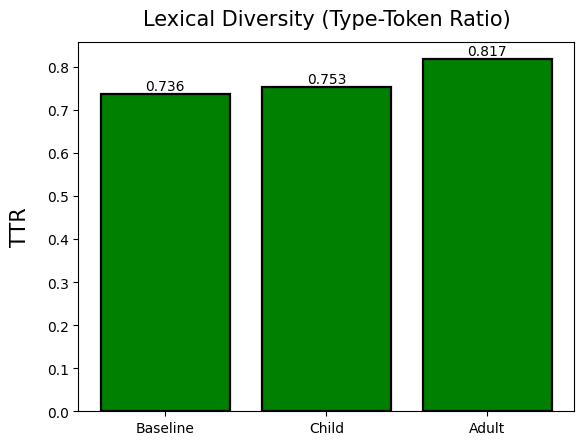

In [ ]:
plt.figure()

plt.bar(
    x,
    lexical_means,
    edgecolor="black",
    linewidth=1.6,
    color="green"
)

plt.xticks(x, labels)
plt.title("Lexical Diversity (Type-Token Ratio)", fontsize=15, pad=12)
plt.ylabel("TTR", fontsize=15, labelpad=12)

for i, v in enumerate(lexical_means):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

**SENTIMENT**


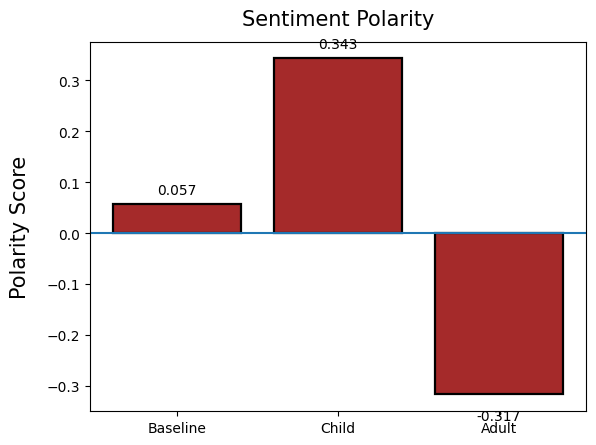

In [ ]:
plt.figure()

plt.bar(
    x,
    sentiment_means,
    edgecolor="black",
    linewidth=1.6,
    color="brown"
)

plt.xticks(x, labels)
plt.title("Sentiment Polarity", fontsize=15, pad=12)
plt.ylabel("Polarity Score", fontsize=15, labelpad=12)

plt.axhline(0)  # Neutral baseline

for i, v in enumerate(sentiment_means):
    plt.text(i, v + 0.02 if v > 0 else v - 0.05, f"{v:.3f}", ha='center')

plt.show()

**ENTROPY**

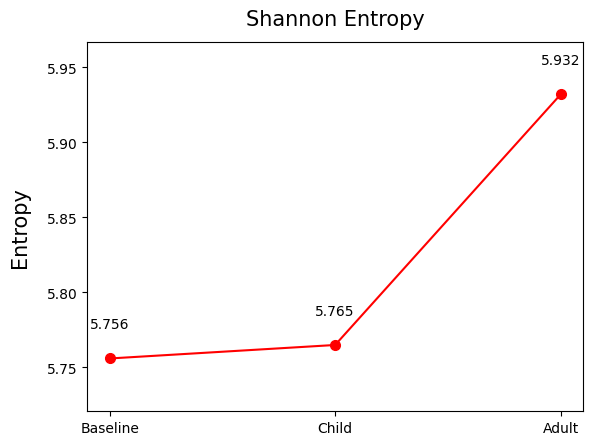

In [ ]:
# Sort for better visual clarity
sorted_idx = np.argsort(entropy_means)

entropy_sorted = entropy_means[sorted_idx]
labels_sorted = labels[sorted_idx]

x_sorted = np.arange(len(entropy_sorted))

plt.figure()

plt.plot(
    x_sorted,
    entropy_sorted,
    marker='o',
    linestyle='-',
    color='red',
    linewidth=1.5,
    markersize=7
)

plt.xticks(x_sorted, labels_sorted)
plt.title("Shannon Entropy", fontsize=15, pad=12)
plt.ylabel("Entropy", fontsize=15, labelpad=12)

for i, v in enumerate(entropy_sorted):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.margins(y=0.2)
plt.show()

**MULTIMODAL**

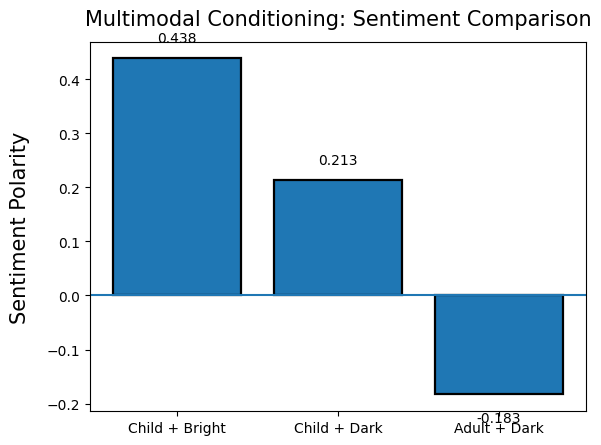

In [ ]:
labels_multi = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]  # your actual values

x_multi = np.arange(len(labels_multi))

plt.figure()

plt.bar(
    x_multi,
    sentiment_values,
    edgecolor="black",
    linewidth=1.6
)

plt.xticks(x_multi, labels_multi)
plt.title("Multimodal Conditioning: Sentiment Comparison", fontsize=15, pad=12)
plt.ylabel("Sentiment Polarity", fontsize=15, labelpad=12)

plt.axhline(0)

for i, v in enumerate(sentiment_values):
    plt.text(i, v + 0.03 if v > 0 else v - 0.05, f"{v:.3f}", ha='center')

plt.show()